# Дерево решений для классификации

## Сегодня на практическом занятии:
1. Узнаем, как считать количество вопросов, которое будет задаваться деревом решений на конкретном шаге
2. Разберемся со структурой дерева решений
3. Реализуем функцию подсчета критерия информативности Джини
4. Реализуем функцию подсчета прироста информации
5. Вручную пройдемся по процессу построения дерева решений

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

### Получение данных

Будем работать с набором данных для задачи классификации - данные по сердечно сосудистым заболеваниям, довольно стандартный набор для изучения машинного обучения, но его нет в `sklearn'e`. Поэтому скачиваем данные со стороны, с google диска.

Ссылка на google drive: https://drive.google.com/file/d/1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G


In [15]:
!wget 'https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G' -O cardio.csv

"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
"id" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


В задаче предалагается предсказать наличие сердечно-сосудистых заболеваний по результатам классического врачебного осмотра. Датасет сформирован 3 групп признаков:

Объективные признаки:
- Возраст (в днях)
- Рост
- Вес
- Пол

Результаты измерения:

- Артериальное давление верхнее и нижнее
- Холестерин (три группы: норма, выше нормы, значительно выше нормы)
- Глюкоза (три группы: норма, выше нормы, значительно выше нормы)

Субъективные признаки (бинарные):

- Курение
- Употребление Алкоголя
- Физическая активность

In [16]:
import pandas as pd
df = pd.read_csv('cardio.csv', sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [17]:
full_features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [18]:
df['age'] = round(df['age'] / 365)

## 1. Вводная

### 1.1 Сколько вопросов будет задано на первом этапе

Посчитайте, сколько вопросов задаст дерево решений в самый первый раз, если использовать все признаки из списка full_features.

In [19]:
# Ваш код здесь
#Можете использовать функцию nunique() 
#не забудьте отнять единичку

count_questions = sum([df[feature].nunique() - 1 for feature in full_features])

print(f'Вопросов будет {count_questions}')

Вопросов будет 737


### 1.2 Упростите задачу

Вопросов получилось достаточно, не будет моделировать столько вопросов, а попробуем уменьшить их количество.

Возьмите только два признака: weight и gluc.
А так же возьмите только 6 первых объектов.

In [20]:
# Ваш код здесь
features = ["weight", "gluc"]
df6 = df[features + [target]].head(6)
df6

,weight,gluc,cardio
0,62.0,1,0
1,85.0,1,1
2,64.0,1,1
3,82.0,1,1
4,56.0,1,0
5,67.0,2,0


### 1.3 Посчитайте еще раз, сколько будет вопросов

In [21]:
# Ваш код здесь
count_questions = sum([df6[feature].nunique() - 1 for feature in features])

print(f'Вопросов будет {count_questions}')

Вопросов будет 6


С таким количеством вопросов уже можем работать и разбираться в устройству дерева решений.

## 2. Устройство дерева решений

### 2.1 Обучите дерево решений

Обучите дерево решений из sklearn'a с атрибутом `random_state=1`.

In [22]:
# Ваш код здесь
tree = DecisionTreeClassifier(random_state=1)
tree.fit(df6[features], df6[target])

DecisionTreeClassifier(random_state=1)

### 2.2 Отрисуйте обученное дерево решений

Нарисуйте дерево решений, которое у вас получилось после обучения. Сделайте отрисовку такой, чтобы можно было понять, какие вопросы задаются

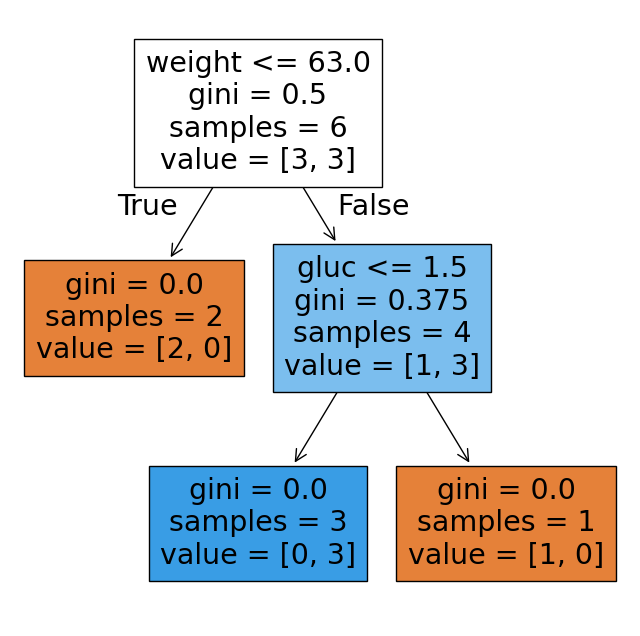

In [23]:
# Ваш код здесь
plt.figure(figsize=(8, 8))
plot_tree(tree, feature_names=features, filled=True);

### 2.3 Посчитайте, сколько вершин получилось

In [24]:
# Ваши выводы здесь можно без кода, просто посчитайте
tree.tree_.node_count

5

### 2.4 Посчитайте, сколько листов получилось

In [25]:
# Ваши выводы здесь, можно без кода, просто посчитайте
tree.tree_.n_leaves

np.int64(3)

### 2.5 Посмотрите, почему не получилось сделать разбиение ещё на два узла в крайнем левом узле.

В узле, где
```
gini=0.5
samples=2
value=[1, 1]
```

In [26]:
# Ваш код/вывод здесь

# где?

## 3. Вспомогательные функции

Для того, что бы дальше сравнивать между собой объекты нужно реализовать две вспомогательные функции.

### 3.1 Функция подсчета критерия Джини

Функция должна принимать список целевых значений, считать критерий информативности и выдавать одно значение - критерий Джини.

Можно было бы опираться на формулу подсчета значения:

$$H(X) = \sum^{K}_{k=1}p_{k}(1-p_{k}) = 1 - \sum_{k=1}^K{p_k^2} ,$$

где $K$ - количество классов в наборе данных $X$,
а $p_k$ - доля объектов класса $k$ в выборке $X$:

In [27]:
def gini(labels):
    """
    на вход labels - целевые значения
    на выходе подсчитанный джини
    """

    #  подсчет количества объектов разных классов
    classes = {}
    for label in labels:
        if label not in classes:
            classes[label] = 0
        classes[label] += 1

    #  расчет критерия
    gini = 0
    for label in classes:
        p = classes[label] / len(labels)
        gini += p * (1 - p)

    return gini

### 3.2 Проверка функции gini

Посчитайте критерий информативности в исходной выборке и вы должны получить точно такое же значение, как и было на визуализации дерева решений в его корне.

In [28]:
# Ваш код здесь
print(f'Самописный Джини в корне дерева {gini(df[target])}')

Самописный Джини в корне дерева 0.49999982


### 3.3 Функция подсчета прироста информации

Функция должна принимать целевые значения левой подвыборки, правой подвыборки и исходной вершины, а выдавать должна одно значение - прирост информации, подсчитанный на критерии информативности Джини.

Можно было пользоваться этой формулой:

$$Q(X_{m}, j, t) = H(X_{m}) - \frac{|X_{l}|}{|X_{m}|}H(X_{l}) - \frac{|X_{r}|}{|X_{m}|}H(X_{r})$$

In [29]:
# Ваш код здесь, реализуйте функцию самостоятельно
def gain(left_labels, right_labels, root_labels):
    p = float(left_labels.shape[0]) / (left_labels.shape[0] + right_labels.shape[0])
    IG = gini(root_labels) - p * gini(left_labels) - (1 - p) * gini(right_labels)

    return IG

Теперь вспомогательные функции готовы можем моделировать работу обученного дерева решений.

## 4. Процесс построения дерева решений

### 4.1 Получение первого вопроса


4.1.1 Пройдитесь по всем возможным вопросам для исходного набора данных


Можете сохранять полученные значения прироста информации в датафрейм в удобную для вас структуру данных.

In [30]:
results = pd.DataFrame(columns=['feature', 'value', 'IG'])

# проход по все признакам
for feature in full_features:
    # проход по всем уникальным значения
    # (при этом можем брать и невалидные вопросы)
    # (у них просто будет нулевой IG)
    for t in df[feature].unique():
        y_left = df[df[feature] <= t][target]
        y_right = df[df[feature] > t][target]
        ig = gain(y_left, y_right, df[target])

        # записываем результаты
        results = pd.concat(
            [
                results, 
                pd.DataFrame({
                'feature': [feature],
                'value': [t],
                'IG': [ig]
                })
            ],
            ignore_index=True)

results


C:\Users\79648\AppData\Local\Temp\ipykernel_4756\1868956327.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat(


,feature,value,IG
0,age,50.0,0.017379
1,age,55.0,0.018574
2,age,52.0,0.018412
3,age,48.0,0.014006
4,age,60.0,0.012738
...,...,...,...
743,smoke,1.0,0.000000
744,alco,0.0,0.000027
745,alco,1.0,0.000000
746,active,1.0,0.000000


4.1.2 Найдите самый лучший вопрос, опираясь на прирост информации

In [31]:
# Ваш код здесь
results.sort_values(["IG"], ascending=False).head()

,feature,value,IG
494,ap_hi,129.0,0.094549
506,ap_hi,128.0,0.094517
511,ap_hi,127.0,0.094319
444,ap_hi,126.0,0.094182
435,ap_hi,125.0,0.094091


4.1.3. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [32]:
# Ваш код здесь
df_left = df[df['ap_hi'] <= 129]
df_right = df[df['ap_hi'] > 129]
len(df_left), len(df_right)
# display(df_left.sort_values(["ap_hi"], ascending=False).head(), df_right.sort_values(["ap_hi"], ascending=False).head())
# df["ap_hi"].max()

(41326, 28674)

4.1.4. Проверьте себя через визуализацию дерева решений

[Text(0.5, 0.8333333333333334, 'ap_hi <= 129.5\ngini = 0.5\nsamples = 70000\nvalue = [35021, 34979]'),
 Text(0.25, 0.5, 'age <= 54.5\ngini = 0.434\nsamples = 41326\nvalue = [28160, 13166]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.375, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.75, 0.5, 'ap_hi <= 138.5\ngini = 0.364\nsamples = 28674\nvalue = [6861, 21813]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.875, 0.16666666666666666, '\n  (...)  \n')]

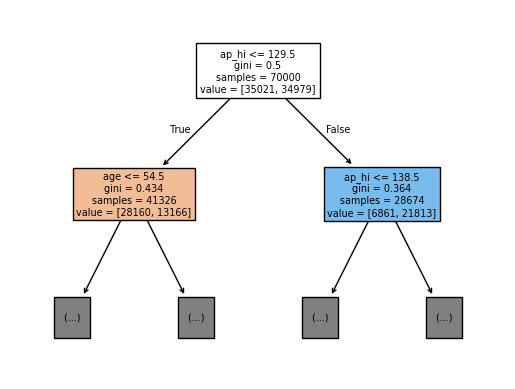

In [33]:
# Ваш код здесь
tree = DecisionTreeClassifier(random_state=1)
tree.fit(df[full_features], df[target])
plot_tree(tree, feature_names=full_features, filled=True, max_depth=1)

### 4.2 Получение второго вопроса


4.2.1. Глядя на df_left и df_right, посмотрите, где можно сделать ещё разбиение

In [34]:
# Ваш вывод здесь
results_left = pd.DataFrame(columns=['feature', 'value', 'IG'])

# проход по все признакам
for feature in full_features:
    # проход по всем уникальным значения
    # (при этом можем брать и невалидные вопросы)
    # (у них просто будет нулевой IG)
    for t in df_left[feature].unique():
        y_left = df_left[df_left[feature] <= t][target]
        y_right = df_left[df_left[feature] > t][target]
        ig = gain(y_left, y_right, df_left[target])

        # записываем результаты
        results_left = pd.concat(
            [
                results_left, 
                pd.DataFrame({
                'feature': [feature],
                'value': [t],
                'IG': [ig]
                })
            ],
            ignore_index=True)

results_left.sort_values(["IG"], ascending=False).head()

C:\Users\79648\AppData\Local\Temp\ipykernel_4756\3212672150.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_left = pd.concat(


,feature,value,IG
3,age,54.0,0.020176
26,age,55.0,0.019727
16,age,53.0,0.019151
5,age,52.0,0.019099
10,age,56.0,0.018065


4.2.2. Пройдитесь по всем признакам в выбранной подвыборке

In [35]:
# Ваш код здесь

results_right = pd.DataFrame(columns=['feature', 'value', 'IG'])

# проход по все признакам
for feature in full_features:
    # проход по всем уникальным значения
    # (при этом можем брать и невалидные вопросы)
    # (у них просто будет нулевой IG)
    for t in df_right[feature].unique():
        y_left = df_right[df_right[feature] <= t][target]
        y_right = df_right[df_right[feature] > t][target]
        ig = gain(y_left, y_right, df_right[target])

        # записываем результаты
        results_right = pd.concat(
            [
                results_right, 
                pd.DataFrame({
                'feature': [feature],
                'value': [t],
                'IG': [ig]
                })
            ],
            ignore_index=True)

results_right.sort_values(["IG"], ascending=False).head()

C:\Users\79648\AppData\Local\Temp\ipykernel_4756\1181651228.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_right = pd.concat(


,feature,value,IG
370,ap_hi,138.0,0.025114
379,ap_hi,139.0,0.025053
348,ap_hi,137.0,0.025001
338,ap_hi,135.0,0.024969
368,ap_hi,136.0,0.024910


4.2.3 Найдите самый лучший вопрос, опираясь на прирост информации

In [36]:
# Ваш код здесь

# +

4.2.4. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [37]:
# Ваш код здесь
df_left_left = df_left[df_left['age'] <= 54]
df_left_right = df_left[df_left['age'] > 54]
len(df_left_left), len(df_left_right)

(25192, 16134)

4.2.5. Проверьте себя через визуализацию дерева решений

In [38]:
# Ваш код здесь
df_right_left = df_right[df_right['ap_hi'] <= 138]
df_right_right = df_right[df_right['ap_hi'] > 138]
len(df_right_left), len(df_right_right)

(9263, 19411)

4.2.6. Если что-то не сошлось, посмотрите, в чем может быть проблема

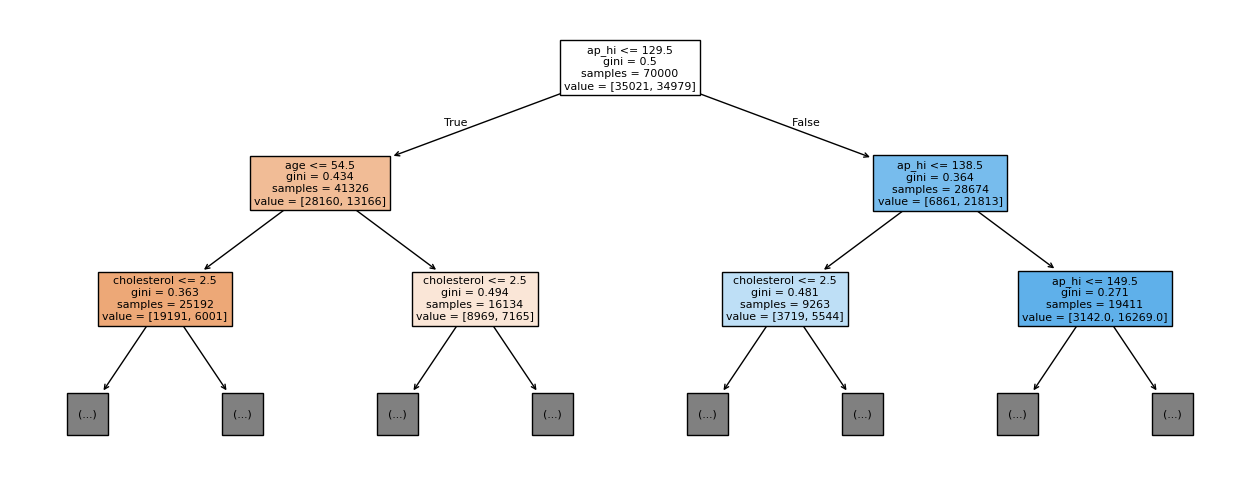

In [39]:
# Ваш код/вывод здесь. Вспомните6 что есть разные стратегии, как задавать вопросы к данным
_, ax = plt.subplots(figsize=(16, 6))
plot_tree(tree, feature_names=full_features, filled=True, max_depth=2, ax=ax);

## Резюме

Сегодня на практическом занятии:
1. Узнали, как считать количество вопросов, которое будет задаваться деревом решений на конкретном шаге
2. Разобрались со структурой дерева решений
3. Реализовали функцию подсчета критерия информативности Джини
4. Реализовали функцию подсчета прироста информации
5. Вручную прошлись по процессу построения дерева решений